## 3.0 Introduction

This homework covers Lecture 3: the dataset as a matrix, indexing and slicing, column statistics, standardization, and visualization. You'll apply every tool from lecture to a new, messier dataset — the **[Palmer Penguins](https://archive.ics.uci.edu/dataset/690/palmer+penguins-3)**. If you find yourself struggling with this assignment make sure you understand what we did with the **Iris** dataset in Lecture 3 before moving on to this dataset. 

In [3]:
# Run this cell first
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 3.1 Loading and Inspecting the Dataset

The **Palmer Penguins** dataset contains measurements of 344 penguins from three species — Adelie, Chinstrap, and Gentoo — collected at Palmer Station, Antarctica. The four numerical features are:

1. `bill_length_mm`
2. `bill_depth_mm`
3. `flipper_length_mm`
4. `body_mass_g`

The file `penguins.csv` lives in the course GitHub repository under `datasets/`. You loaded the Iris dataset from the same repository in Lecture 3.

In [4]:
# Construct the URL and load the dataset
url = 
df = 

df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [5]:
# Dimensions and column summary
print('Shape:', df.shape)
print()
df.info()

Shape: (344, 7)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


### Missing Values

Notice that unlike the `iris.csv` dataset we saw in Lecture 3, this dataset has missing values. Missing values are common in real data — a sensor failed, a field was left blank, a measurement was recorded incorrectly and later removed. They show up in pandas as `NaN` (Not a Number).

We have a variety of strategies for handling missing values, and we'll explore several of them over the course of the term. For now we'll do the simplest (but not necessarily the best) thing: **drop any row that contains at least one `NaN`**. This results in those penguins fall out of the dataset entirely.

To see exactly where the missing values are, pandas gives us two tools:

- `.isnull()` — returns a DataFrame of `True`/`False` values, one per entry, indicating whether that entry is missing
- `.isnull().sum()` — sums the `True` values down each column, giving a count of missing entries per feature.

In [6]:
# Count missing values in each column
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


Now drop all rows with missing values using `.dropna()` and call the result `df_clean`. Run `df_clean.shape` to confirm how many rows remain.

**Exercise 1.** \_\_\_ rows remain in `df_clean` after dropping missing values.

In [7]:
df_clean = df.dropna()

# Your code here


(333, 7)

**Exercise 2.** Run `df_clean.describe()` and use it to find and report the standard deviation of `bill_depth_mm`. Be sure to round your answer to 4 decimal places (as usual).

In [8]:
# Your code here


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,333.000000,333.000000,333.000000,333.000000
mean,43.992793,17.164865,200.966967,4207.057057
std,5.468668,1.969235,14.015765,805.215802
min,32.100000,13.100000,172.000000,2700.000000
25%,39.500000,15.600000,190.000000,3550.000000
50%,44.500000,17.300000,197.000000,4050.000000
75%,48.600000,18.700000,213.000000,4775.000000
max,59.600000,21.500000,231.000000,6300.000000


## 3.2 Extracting the Matrix

Run the code cell below without modification to extract the four numerical feature columns from `df_clean` as a NumPy matrix `X`, and encode the species column as integer labels `y`.

In [9]:
feature_names = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X = df_clean[feature_names].to_numpy()
y = pd.Categorical(df_clean['species']).codes   # 0 = Adelie, 1 = Chinstrap, 2 = Gentoo
species_names = df_clean['species'].unique()

print('X shape:', X.shape)
print('Species:', species_names)

X shape: (333, 4)
Species: ['Adelie' 'Chinstrap' 'Gentoo']


**Exercise 3.** Extract the 5th data vector $\mathbf{x}_5$ (0-indexed, so index 4) from $X$. The 3rd entry of $\mathbf{x}_5$ is \_\_\_.

In [11]:
# Your code here


array([  39.3,   20.6,  190. , 3650. ])

**Exercise 4.** Extract the flipper length column from $X$ using indexing and . The first entry of the flipper length column is \_\_\_.

In [12]:
# Your code here


array([181., 186., 195., 193., 190., 181., 195., 182., 191., 198., 185.,
       195., 197., 184., 194., 174., 180., 189., 185., 180., 187., 183.,
       187., 172., 180., 178., 178., 188., 184., 195., 196., 190., 180.,
       181., 184., 182., 195., 186., 196., 185., 190., 182., 190., 191.,
       186., 188., 190., 200., 187., 191., 186., 193., 181., 194., 185.,
       195., 185., 192., 184., 192., 195., 188., 190., 198., 190., 190.,
       196., 197., 190., 195., 191., 184., 187., 195., 189., 196., 187.,
       193., 191., 194., 190., 189., 189., 190., 202., 205., 185., 186.,
       187., 208., 190., 196., 178., 192., 192., 203., 183., 190., 193.,
       184., 199., 190., 181., 197., 198., 191., 193., 197., 191., 196.,
       188., 199., 189., 189., 187., 198., 176., 202., 186., 199., 191.,
       195., 191., 210., 190., 197., 193., 199., 187., 190., 191., 200.,
       185., 193., 193., 187., 188., 190., 192., 185., 190., 184., 195.,
       193., 187., 201., 192., 196., 193., 188., 19

**Exercise 5.** Use boolean masking to extract the submatrix of Adelie penguins (`y == 0`). Call it `X_adelie` and print its shape. `X_adelie` has \_\_\_ rows.

In [13]:
X_adelie = 

print('X_adelie shape:', X_adelie.shape)

X_adelie shape: (146, 4)


Use `df_clean['species'].value_counts()` to check how many penguins of each species are in the cleaned dataset. Does the Adelie count match `X_adelie.shape[0]`?

In [14]:
# Your code here


species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

## 3.3 Column Statistics as Linear Algebra

Recall from Lecture 3:

$$\bar{x} = \frac{1}{n}\mathbf{1}^T\mathbf{x} \qquad \sigma = \text{RMS}(\tilde{\mathbf{x}}) = \frac{\|\tilde{\mathbf{x}}\|}{\sqrt{n}}, \qquad \tilde{\mathbf{x}} = \mathbf{x} - \bar{x}\mathbf{1}$$

**Exercise 6.** Let $\mathbf{x}$ be the bill length column. Compute its mean using the dot product formula $\frac{1}{n}\mathbf{1}^T\mathbf{x}$, then verify it matches `np.mean(x)`. $\bar{x} = $ \_\_\_.

In [15]:
x = X[??, ??]       # Replace ?? to get x to be bill length
n = x.shape[??]     # number of entries; .shape generalizes to matrices, len() does not

ones  = np.ones(n)
x_bar = # Finish this by calculating a dot product. 

print(f'Mean via dot product: {x_bar:.4f}')
print(f'Mean via np.mean():   {np.mean(x):.4f}')

Mean via dot product: 14649.6000
Mean via np.mean():   43.9928


**Exercise 7.** Let $\mathbf{x}$ be the body mass column. Compute the mean-centered vector $\tilde{\mathbf{x}} = \mathbf{x} - \bar{x}\mathbf{1}$, verify its mean is essentially zero, then compute the standard deviation as $\sigma = \|\tilde{\mathbf{x}}\| / \sqrt{n}$ and verify it matches `np.std(x)`. $\sigma = $ \_\_\_.

In [17]:
x = X[??, ??]       # body mass
n = ??

x_bar      = np.mean(x)
x_centered = # Finish this. 

# Verify mean is ~0
print(f'Mean of centered vector: {np.mean(x_centered):.10f}')

# Standard deviation via RMS: norm(x_centered) / sqrt(n)
sigma = # Finish this.
print(f'Std via RMS:      {sigma:.4f}')
print(f'Std via np.std(): {np.std(x):.4f}')   # np.std() uses ddof=0 by default

Mean of centered vector: -0.0000000000
Std via RMS:      804.0059
Std via np.std(): 804.0059


Compute the mean, standard deviation, and norm for all four feature columns. Use `np.mean()` and `np.std()` — no pandas methods.

In [18]:
# f-string formatting: {value:<22} left-aligns in 22 characters, {value:>10} right-aligns in 10
print(f"{'Feature':<22} {'Mean':>10} {'Std':>10} {'Norm':>10}")
print('-' * 55)
for j, name in enumerate(feature_names):
    col = X[:, j]
    col_mean = 
    col_std  = 
    col_norm = 
    print(f'{name:<22} {col_mean:>10.4f} {col_std:>10.4f} {col_norm:>10.4f}')

Feature                      Mean        Std       Norm
-------------------------------------------------------
bill_length_mm            43.9928     5.4605   808.9535
bill_depth_mm             17.1649     1.9663   315.2778
flipper_length_mm        200.9670    13.9947  3676.1842
body_mass_g             4207.0571   804.0059 78160.9637


Look at the norms. Body mass is in grams while the other three features are in millimeters. The norm of the body mass column is orders of magnitude larger than the others. Why would this be a problem for a distance-based algorithm like k-Means?

## 3.4 Normalize vs. Standardize

Recall from Lecture 3:

- **Normalization** produces a unit vector: $\hat{\mathbf{x}} = \mathbf{x} / \|\mathbf{x}\|$, so $\|\hat{\mathbf{x}}\| = 1$
- **Standardization** produces mean $0$, std $1$: $\mathbf{z} = (\mathbf{x} - \bar{x}\mathbf{1}) / \sigma$, so $\|\mathbf{z}\| = \sqrt{n}$

**Exercise 8.** Standardize the flipper length column using NumPy. Verify that the mean of $\mathbf{z}$ is essentially $0$, the std is essentially $1$, and $\|\mathbf{z}\| = \sqrt{n}$. $\|\mathbf{z}\| = $ \_\_\_.

In [19]:
x = X[??, ??]   # flipper length

# Standardize: mean center, then scale by 1/sigma
z = 

print(f'Mean: {np.mean(z):.4f}')
print(f'Std:  {np.std(z):.4f}')
print(f'Norm: {np.linalg.norm(z):.4f}')
print(f'sqrt({x.shape[0]}): {np.sqrt(x.shape[0]):.4f}')

Mean: 0.0000
Std:  1.0000
Norm: 18.2483
sqrt(333): 18.2483


Standardize all four feature columns and store the result as `X_std` of shape $(n, 4)$. Verify that every column has norm $\sqrt{n}$.

In [20]:
X_std = np.zeros_like(X, dtype=float)
for j in range(4):
    col = X[:, j]
    X_std[:, j] = 

for j, name in enumerate(feature_names):
    print(f'{name:<22} norm = {np.linalg.norm(X_std[:, j]):.4f}')

bill_length_mm         norm = 18.2483
bill_depth_mm          norm = 18.2483
flipper_length_mm      norm = 18.2483
body_mass_g            norm = 18.2483


Plot histograms of the raw and standardized body mass columns side by side by running the cell below without modification. What changed and what stayed the same?

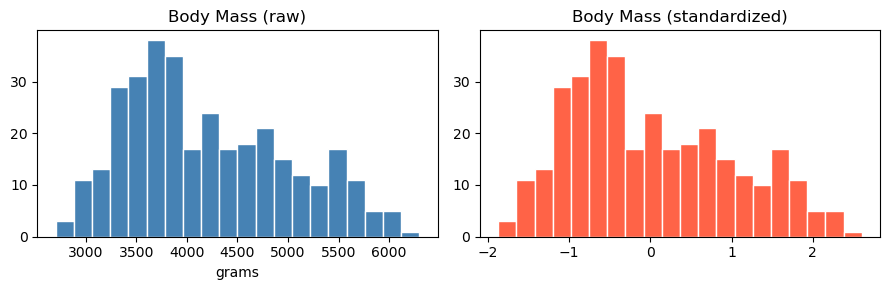

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3))

axes[0].hist(X[:, 3], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Body Mass (raw)')
axes[0].set_xlabel('grams')

axes[1].hist(X_std[:, 3], bins=20, color='tomato', edgecolor='white')
axes[1].set_title('Body Mass (standardized)')

plt.tight_layout()
plt.show()

## 3.5 Centroids

**Exercise 9.** Compute the centroid $\bar{\mathbf{x}}_k$ for each of the three species using boolean masking and `np.mean(..., axis=0)`. The flipper length entry of the Adelie centroid $\bar{\mathbf{x}}_0$ is \_\_\_.

In [27]:
for k, species in enumerate(species_names):
    centroid = 
    print(f'{species} centroid x-bar_{k}: {np.round(centroid, 4)}')

Adelie centroid x-bar_0: [  38.824    18.3473  190.1027 3706.1644]
Chinstrap centroid x-bar_1: [  48.8338   18.4206  195.8235 3733.0882]
Gentoo centroid x-bar_2: [  47.5681   14.9966  217.2353 5092.437 ]


Make a scatter plot of bill length vs. flipper length, colored by species. Use `steelblue`, `tomato`, and `seagreen`. Add the centroid of each species as a star marker, as we did for Iris in Lecture 3. Do the three species form visible clusters?

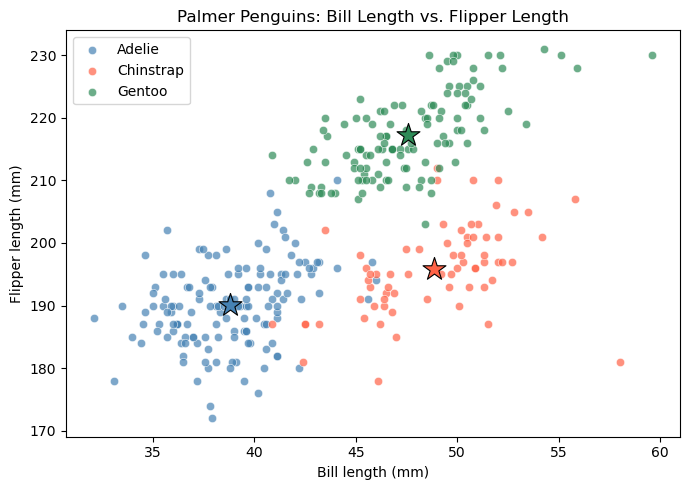

In [28]:
colors = ['steelblue', 'tomato', 'seagreen']

fig, ax = plt.subplots(figsize=(7, 5))

for k, species in enumerate(species_names):
    mask     = (y == k)
    centroid = np.mean(X[mask, :], axis=0)

    ax.scatter(X[mask, 0], X[mask, 2],
               color=colors[k], label=species, alpha=0.7,
               edgecolors='white', linewidth=0.5)
    ax.scatter(centroid[0], centroid[2],
               color=colors[k], marker='*', s=300,
               edgecolors='black', linewidth=0.8)

ax.set_xlabel('Bill length (mm)')
ax.set_ylabel('Flipper length (mm)')
ax.set_title('Palmer Penguins: Bill Length vs. Flipper Length')
ax.legend()
plt.tight_layout()
plt.show()

## 3.6 Visualization

Run the code cell below without modification to generate some scatterplots. 

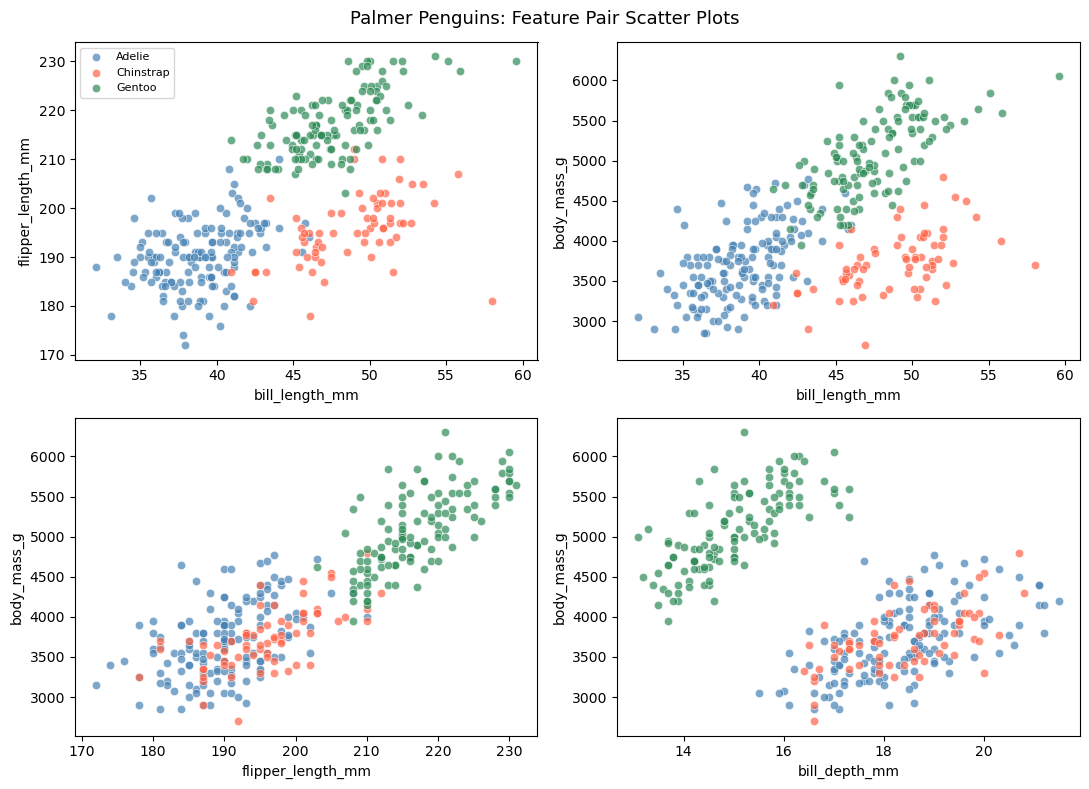

In [30]:
# Scatter plots: four feature pairs chosen to show a range of cluster separation
pairs = [
    (0, 2, 'bill_length_mm',    'flipper_length_mm'),
    (0, 3, 'bill_length_mm',    'body_mass_g'),
    (2, 3, 'flipper_length_mm', 'body_mass_g'),
    (1, 3, 'bill_depth_mm',     'body_mass_g'),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

for ax, (j1, j2, name1, name2) in zip(axes.flat, pairs):
    for k, species in enumerate(species_names):
        mask = (y == k)
        ax.scatter(X[mask, j1], X[mask, j2],
                   color=colors[k], label=species, alpha=0.7,
                   edgecolors='white', linewidth=0.5)
    ax.set_xlabel(name1)
    ax.set_ylabel(name2)

axes[0, 0].legend(fontsize=8)
plt.suptitle('Palmer Penguins: Feature Pair Scatter Plots', fontsize=13)
plt.tight_layout()
plt.show()

**Exercise 10.** Based on the scatter plots above, which feature pair appears to have the strongest linear relationship between the two variables across all three species?

A) bill_length_mm vs flipper_length_mm

B) bill_length_mm vs body_mass_g

C) flipper_length_mm vs body_mass_g

D) bill_depth_mm vs body_mass_g

## Free Response

The following questions are for your own understanding and are not collected.

**Exercise.** The Penguins dataset had missing values; Iris did not. Why is it reasonable to drop rows with missing values here, rather than trying to fill them in? When might dropping rows be a bad idea?

**Exercise.** Look at the norms of the raw feature columns you computed in Section 3.3. Body mass is measured in grams while the other features are in millimeters. Explain concretely what would happen if you ran k-means on the raw (unstandardized) feature matrix.

**Exercise.** You showed above that Pearson correlation is cosine similarity of the mean-centered vectors. What does $r = 1$ mean geometrically, in terms of $\tilde{\mathbf{x}}$ and $\tilde{\mathbf{z}}$? What about $r = 0$? What about $r = -1$?

**Exercise.** The centroid $\bar{\mathbf{x}}_k$ is the mean data vector of all points in cluster $k$. Explain in your own words why it is a natural representative of the cluster. *(Hint: think about what quantity it minimizes.)*